<div>
  <img src="https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEjADOBkb45bo4A5QF2s88__42KTx2GUlpF6O5XVSCXUvzCnbugnZkDLi37LMs446WLBdi4o-yGNJ6wJh3DJPSRS5sAf4dm5Ua8uDb5d0HRpNETtxXWnr0j6-fz4CMe6NlCXcYkeD47ArYN-/s1600/logo-fondoazul.jpg" width="250px">
  

  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/9/98/The_Simpsons_yellow_logo.svg/1920px-The_Simpsons_yellow_logo.svg.png" width="200px">
</div>

<hr>

# **Informe Técnico**

## **Implementación de Redes Neuronales Multicapa (MLP) para la Clasificación de Imágenes**

### **Caso de estudio: Personajes de Los Simpsons**

<br>

**Integrantes:** Sebastián Almendras

**Profesor:** Juan Burgueño Alcalde
  
**Asignatura:** Deep Learning - 901D_OLS



---



## **Introduccion**

En este trabajo se implementa un modelo de Deep Learning para la clasificación de imágenes de personajes de Los Simpsons.

El objetivo es desarrollar una red neuronal artificial tipo MLP (Multilayer Perceptron), evaluando su desempeño mediante métricas como accuracy, precision, recall y F1-score.

Se analizará el impacto de distintos hiperparámetros y técnicas de optimización, con el fin de mejorar el rendimiento del modelo.



---



## **Importaciones**

En esta sección se importan las librerías necesarias para el desarrollo del modelo de clasificación de imágenes.

Además, se cargan y descomprimen los datasets proporcionados, los cuales contienen imágenes de personajes de Los Simpson organizadas por personaje.

In [ ]:
# Librería para procesamiento de imágenes
import cv2

# Manejo de archivos y directorios
import os

# Cálculo numérico
import numpy as np

# Búsqueda de archivos
import glob

# Visualización de gráficos
import matplotlib.pyplot as plt

# Framework de Deep Learning
import tensorflow as tf
from tensorflow import keras

# Modelo secuencial para la red neuronal
from tensorflow.keras.models import Sequential

# Capas del modelo
from tensorflow.keras.layers import Dense, Dropout

# Optimizador
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

# Callbacks para el entrenamiento
from tensorflow.keras.callbacks import EarlyStopping

# Gráficos
import pandas as pd
import seaborn as sns

# Métricas de evaluación
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# División de datos
from sklearn.model_selection import train_test_split

# Descomprimir archivos subidos manualmente
!tar -xzf simpsons_train.tar.gz
!tar -xzf simpsons_test.tar.gz



---



## **Clases y tamaño de imagen**

Se define un diccionario que asigna un número a cada personaje, permitiendo representar las clases en formato numérico para el modelo. Además, se establece un tamaño fijo de imagen (64x64 píxeles) para estandarizar las entradas y facilitar el entrenamiento de la red neuronal.

In [ ]:
# Esta variable contiene un mapeo de número de clase a personaje.
# Utilizamos sólo los 18 personajes del dataset que tienen más imágenes.
MAP_CHARACTERS = {
    0: 'abraham_grampa_simpson', 1: 'apu_nahasapeemapetilon', 2: 'bart_simpson',
    3: 'charles_montgomery_burns', 4: 'chief_wiggum', 5: 'comic_book_guy', 6: 'edna_krabappel',
    7: 'homer_simpson', 8: 'kent_brockman', 9: 'krusty_the_clown', 10: 'lisa_simpson',
    11: 'marge_simpson', 12: 'milhouse_van_houten', 13: 'moe_szyslak',
    14: 'ned_flanders', 15: 'nelson_muntz', 16: 'principal_skinner', 17: 'sideshow_bob'
}

# Vamos a standarizar todas las imágenes a tamaño 64x64
IMG_SIZE = 64



---



## **Carga del conjunto de entrenamiento**

Esta función carga el conjunto de entrenamiento leyendo las imágenes desde sus carpetas correspondientes a cada personaje.

Cada imagen es redimensionada a un tamaño fijo (64x64) para estandarizar los datos, y se le asigna una etiqueta numérica según el personaje. Finalmente, se almacenan las imágenes y sus etiquetas en arreglos que serán utilizados para entrenar el modelo.

In [ ]:
def load_train_set(dirname, map_characters, verbose=True):
    X_train = []
    y_train = []

    for label, character in map_characters.items():
        path = os.path.join(dirname, character)

        files = os.listdir(path)
        images = [file for file in files if file.lower().endswith(".jpg")]

        if verbose:
            print(f"Leyendo {len(images)} imágenes encontradas de {character}")

        for image_name in images:
            image_path = os.path.join(path, image_name)
            image = cv2.imread(image_path)

            if image is not None:
                image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
                X_train.append(image)
                y_train.append(label)

    return np.array(X_train), np.array(y_train)



---



## **Carga del conjunto de prueba**

Esta función carga el conjunto de prueba leyendo las imágenes desde el directorio correspondiente.

A diferencia del conjunto de entrenamiento, las etiquetas se extraen a partir del nombre del archivo, identificando el personaje asociado a cada imagen. Luego, las imágenes son redimensionadas a un tamaño uniforme (64x64) y se almacenan junto a sus etiquetas numéricas para evaluar el modelo.

In [ ]:
def load_test_set(dirname, map_characters, verbose=True):
    """Esta función funciona de manera equivalente a la función load_train_set
    pero cargando los datos de test."""
    X_test = []
    y_test = []
    reverse_dict = {v: k for k, v in map_characters.items()}
    for filename in glob.glob(dirname + '/*.*'):
        char_name = "_".join(filename.split('/')[-1].split('_')[:-1])
        if char_name in reverse_dict:
            image = cv2.imread(filename)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            X_test.append(image)
            y_test.append(reverse_dict[char_name])
    if verbose:
        print("Leídas {} imágenes de test".format(len(X_test)))
    return np.array(X_test), np.array(y_test)




---



## **Carga de datos**

En esta sección se construyen los conjuntos de datos de entrenamiento y prueba a partir de las imágenes disponibles en los directorios.

Cada imagen es procesada y transformada en una representación numérica junto con su etiqueta correspondiente, permitiendo así su utilización como entrada para el modelo de red neuronal.

In [ ]:
DATASET_TRAIN_PATH = "/content/simpsons"
DATASET_TEST_PATH = "/content/simpsons_testset"

X, y = load_train_set(DATASET_TRAIN_PATH, MAP_CHARACTERS)
X_t, y_t = load_test_set(DATASET_TEST_PATH, MAP_CHARACTERS)

Leyendo 913 imágenes encontradas de abraham_grampa_simpson
Leyendo 623 imágenes encontradas de apu_nahasapeemapetilon
Leyendo 1342 imágenes encontradas de bart_simpson
Leyendo 1193 imágenes encontradas de charles_montgomery_burns
Leyendo 986 imágenes encontradas de chief_wiggum
Leyendo 469 imágenes encontradas de comic_book_guy
Leyendo 457 imágenes encontradas de edna_krabappel
Leyendo 2246 imágenes encontradas de homer_simpson
Leyendo 498 imágenes encontradas de kent_brockman
Leyendo 1206 imágenes encontradas de krusty_the_clown
Leyendo 1354 imágenes encontradas de lisa_simpson
Leyendo 1291 imágenes encontradas de marge_simpson
Leyendo 1079 imágenes encontradas de milhouse_van_houten
Leyendo 1452 imágenes encontradas de moe_szyslak
Leyendo 1454 imágenes encontradas de ned_flanders
Leyendo 358 imágenes encontradas de nelson_muntz
Leyendo 1194 imágenes encontradas de principal_skinner
Leyendo 877 imágenes encontradas de sideshow_bob
Leídas 890 imágenes de test


Como resultado de la carga, se observa la cantidad de imágenes disponibles por cada clase (personaje).

Se aprecia que el dataset no está completamente balanceado, ya que algunos personajes, como Homero Simpson, cuentan con una mayor cantidad de imágenes en comparación con otros, como Nelson Muntz. Esto puede influir en el desempeño del modelo, favoreciendo a las clases con mayor representación.

En total, se cargaron miles de imágenes para entrenamiento y 890 imágenes para el conjunto de prueba, lo que proporciona una base adecuada para el entrenamiento y evaluación del modelo.



---



## **Mezclar datos**

En esta etapa se mezclan aleatoriamente los datos de entrenamiento.

Esto se realiza para evitar que las imágenes estén ordenadas por clase, lo que podría sesgar el aprendizaje del modelo. Al mezclar los datos, se asegura que el modelo reciba ejemplos variados durante el entrenamiento, mejorando su capacidad de generalización.

Si no se realiza esta mezcla, el modelo podría entrenarse con bloques de una misma clase consecutivamente, afectando negativamente su desempeño.

In [ ]:
perm = np.random.permutation(len(X))
X, y = X[perm], y[perm]



---



## **Preprocesamiento**

Las imágenes fueron normalizadas dividiendo los valores de los píxeles por 255, con el objetivo de mejorar la convergencia del modelo.

Además, se realizó un proceso de "flattening", transformando cada imagen de dimensión (64x64x3) a un vector unidimensional, ya que las redes MLP no pueden trabajar directamente con datos en formato de imagen.

In [ ]:
# Normalizar
X = X / 255.0
X_t = X_t / 255.0

# Aplanar imágenes (CLAVE)
X = X.reshape(X.shape[0], -1)
X_t = X_t.reshape(X_t.shape[0], -1)

print("Shape final:", X.shape)

Shape final: (18992, 12288)




---



## **División de datos en entrenamiento y validación**

En esta etapa se divide el conjunto de datos en dos partes: entrenamiento y validación.

El conjunto de entrenamiento se utiliza para entrenar el modelo, mientras que el conjunto de validación permite evaluar su desempeño durante el entrenamiento y detectar posibles problemas como el sobreajuste (overfitting).

Se utiliza un 80% de los datos para entrenamiento y un 20% para validación, lo que permite obtener una estimación confiable del rendimiento del modelo antes de evaluarlo con el conjunto de prueba.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)



---



# **Modelo MLP**

En esta sección se implementa un modelo de red neuronal multicapa (MLP) para la clasificación de imágenes de personajes de Los Simpson.

El objetivo no es solo entrenar un modelo, sino analizar el impacto de distintas configuraciones sobre su rendimiento. Para ello, se adopta un enfoque experimental, en el cual se define un modelo base y posteriormente se realizan variaciones controladas sobre sus componentes principales.

Entre los aspectos evaluados se encuentran las funciones de activación, el uso de técnicas de regularización, distintos optimizadores y ajustes de hiperparámetros como learning rate y batch size.

Este enfoque permite identificar la combinación más adecuada para el problema, justificando las decisiones tomadas en base a resultados cuantitativos.



---



## **Modelo base**



Se define un modelo MLP con dos capas ocultas (128 y 64 neuronas) y función de activación ReLU, adecuada para capturar relaciones no lineales.

La capa de salida utiliza softmax para clasificación multiclase (18 personajes), y se emplea el optimizador Adam con learning rate 0.001.

Además, se aplica Early Stopping con patience=5, lo que significa que el entrenamiento se detiene si la pérdida de validación no mejora durante 5 épocas consecutivas, evitando sobreajuste y ahorrando tiempo de entrenamiento.

In [ ]:
model_base = Sequential([
    Dense(128, activation='relu', input_shape=(X.shape[1],)),
    Dense(64, activation='relu'),
    Dense(18, activation='softmax')
])

model_base.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_base = model_base.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 15s 27ms/step - accuracy: 0.2144 - loss: 2.5809 - val_accuracy: 0.2848 - val_loss: 2.3418
Epoch 2/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.3361 - loss: 2.1857 - val_accuracy: 0.3593 - val_loss: 2.1492
Epoch 3/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.3796 - loss: 2.0504 - val_accuracy: 0.3830 - val_loss: 2.0418
Epoch 4/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.4077 - loss: 1.9462 - val_accuracy: 0.3904 - val_loss: 2.0370
Epoch 5/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.4348 - loss: 1.8745 - val_accuracy: 0.4014 - val_loss: 1.9963
Epoch 6/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.4538 - loss: 1.7908 - val_accuracy: 0.4225 - val_loss: 1.9068
Epoch 7/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.4680 - loss: 1.7425 - val_accuracy: 0.4270 - val_loss: 1.9048
Epoch 8/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.4878 - loss: 1

## Resultado obtenido:

El modelo logró una precisión (accuracy) del 50,51% en validación. Considerando que hay 18 personajes, es un resultado inicial sólido (muy superior al azar).

El Early Stopping detuvo el proceso en la época 24, recuperando los mejores pesos de la época 19. Esto evitó que el modelo perdiera tiempo intentando mejorar una pérdida que ya se había estancado.

Mientras la precisión en entrenamiento siguió subiendo hasta 64%, la de validación dejó de mejorar. Esto justifica la necesidad de probar técnicas de regularización en los siguientes experimentos.



---



## **Experimento 1: Funcion activación: Relu vs Sigmoidea vs Tanh**

En este experimento se evalúa el impacto de distintas funciones de activación en el rendimiento del modelo. Se comparan ReLU, sigmoid y tanh.

Las funciones de activación determinan cómo la red neuronal aprende representaciones no lineales, por lo que su elección es fundamental para el desempeño del modelo.

## **Función Sigmoid**

En este experimento se reemplazó la función de activación ReLU por sigmoid en todas las capas ocultas, manteniendo la misma arquitectura del modelo base. El objetivo fue evaluar cómo afecta esta función al proceso de aprendizaje.

In [ ]:
model_sigmoid = Sequential([
    Dense(128, activation='sigmoid', input_shape=(X.shape[1],)),
    Dense(64, activation='sigmoid'),
    Dense(18, activation='softmax')
])

model_sigmoid.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_sigmoid = model_sigmoid.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.1295 - loss: 2.7731 - val_accuracy: 0.1429 - val_loss: 2.7169
Epoch 2/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.1667 - loss: 2.6558 - val_accuracy: 0.1845 - val_loss: 2.6040
Epoch 3/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.1932 - loss: 2.5774 - val_accuracy: 0.1769 - val_loss: 2.5817
Epoch 4/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.1933 - loss: 2.5504 - val_accuracy: 0.2087 - val_loss: 2.5250
Epoch 5/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.2133 - loss: 2.5027 - val_accuracy: 0.2001 - val_loss: 2.4936
Epoch 6/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.2135 - loss: 2.4980 - val_accuracy: 0.2216 - val_loss: 2.4622
Epoch 7/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.2265 - loss: 2.4571 - val_accuracy: 0.2261 - val_loss: 2.4501
Epoch 8/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.2296 - loss: 2

## Resultado Obtenido:

A diferencia de ReLU, la función Sigmoide necesitó 31 épocas para alcanzar su mejor punto.

Logró un accuracy de validación máximo de 35,72% (en la época 26). Es notablemente más bajo que el 50,51% del modelo base, lo que confirma que para imágenes con alta variabilidad, esta función no logra extraer características tan bien como ReLU.

El modelo se detuvo al no lograr bajar la pérdida de validación (val_loss) por debajo de 2.14. La Sigmoide tiende a sufrir del problema de "desvanecimiento de gradiente", lo que limita la capacidad de la red para seguir mejorando una vez que alcanza un nivel básico de acierto.

## **Función Tangente Hiperbólica (tanh)**

In [ ]:
model_tanh = Sequential([
    Dense(128, activation='tanh', input_shape=(X.shape[1],)),
    Dense(64, activation='tanh'),
    Dense(18, activation='softmax')
])

model_tanh.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_tanh = model_tanh.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.1145 - loss: 2.8198 - val_accuracy: 0.0805 - val_loss: 2.8348
Epoch 2/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.1174 - loss: 2.8093 - val_accuracy: 0.1106 - val_loss: 2.8159
Epoch 3/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.1193 - loss: 2.8087 - val_accuracy: 0.1106 - val_loss: 2.8047
Epoch 4/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.1174 - loss: 2.8067 - val_accuracy: 0.1106 - val_loss: 2.8062
Epoch 5/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.1176 - loss: 2.8067 - val_accuracy: 0.1106 - val_loss: 2.8232
Epoch 6/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.1176 - loss: 2.8063 - val_accuracy: 0.1106 - val_loss: 2.8021
Epoch 7/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.1179 - loss: 2.8055 - val_accuracy: 0.1106 - val_loss: 2.8068
Epoch 8/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.1192 - loss: 2

## Resultado Obtenido:

El modelo se quedó estancado en un 11,06% de acierto. Esto significa que la red no pudo aprender nada nuevo de las imágenes y se limitó a dar una respuesta fija por puro azar.

Esta función intenta aplastar todos los datos en un rango muy pequeño (entre -1 y 1). Al hacer esto con imágenes, la información se "amontona" en los extremos de la curva, y la red deja de distinguir qué píxel es importante.

Queda claro que para este caso de los Simpsons, las funciones curvas de rango limitado (como Sigmoide y Tanh) no funcionan bien. ReLU sigue siendo la ganadora porque es más "directa" y no bloquea el paso de la información cuando el modelo está aprendiendo.

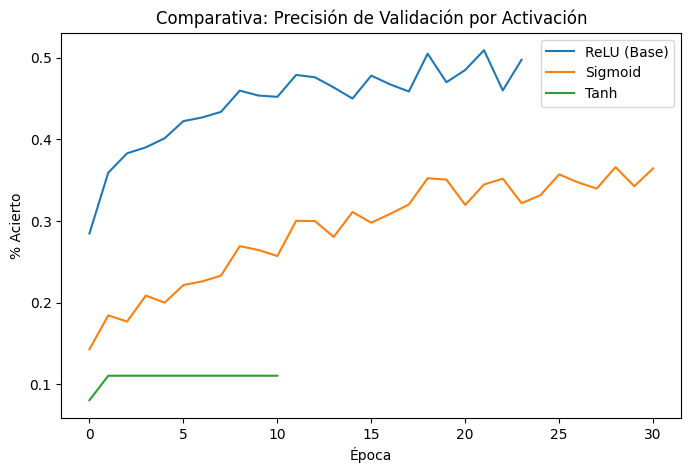

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_base.history['val_accuracy'], label='ReLU (Base)')
plt.plot(history_sigmoid.history['val_accuracy'], label='Sigmoid')
plt.plot(history_tanh.history['val_accuracy'], label='Tanh')

plt.title('Comparativa: Precisión de Validación por Activación')
plt.xlabel('Época')
plt.ylabel('% Acierto')
plt.legend()
plt.show()

## **Análisis: ReLU vs. Sigmoid vs. Tanh**

Se observa que ReLU (modelo base) alcanza el mejor rendimiento, superando el 50% de accuracy, con una tendencia de aprendizaje rápida y estable. Esto indica que logra capturar mejor los patrones de las imágenes.

Por otro lado, Sigmoid presenta un crecimiento más lento y se estanca alrededor del 36%, lo que evidencia dificultades para seguir aprendiendo a medida que avanzan las épocas.

Finalmente, Tanh no logra aprender, manteniéndose cerca del 11%, equivalente al azar. Esto sugiere un problema de desvanecimiento del gradiente, impidiendo que la red ajuste sus pesos correctamente.



---



## **Experimento 2: Implementar diferentes optimizadores**

Se comparan distintos optimizadores, incluyendo Adam, SGD con momentum y RMSProp.

Los optimizadores son responsables de actualizar los pesos del modelo durante el entrenamiento, por lo que su elección impacta directamente en la eficiencia y calidad del aprendizaje.

## **SGD + Momentum**

Se utiliza SGD con Momentum, que acumula 'impulso' de los pasos anteriores, lo que permite que el modelo avance más rápido y no se quede atrapado en pequeños errores o baches del camino que podrían frenar el aprendizaje. Así, logra encontrar una mejor configuración para reconocer a los personajes.


In [ ]:
model_sgd = Sequential([
    Dense(128, activation='relu', input_shape=(X.shape[1],)),
    Dense(64, activation='relu'),
    Dense(18, activation='softmax')
])

model_sgd.compile(
    optimizer=SGD(learning_rate=0.001, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_sgd = model_sgd.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.2198 - loss: 2.5060 - val_accuracy: 0.2616 - val_loss: 2.3420
Epoch 2/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.3511 - loss: 2.1594 - val_accuracy: 0.3743 - val_loss: 2.0812
Epoch 3/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.3968 - loss: 2.0154 - val_accuracy: 0.3888 - val_loss: 2.0342
Epoch 4/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.4284 - loss: 1.9121 - val_accuracy: 0.4314 - val_loss: 1.9178
Epoch 5/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.4557 - loss: 1.8229 - val_accuracy: 0.4388 - val_loss: 1.8734
Epoch 6/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.4791 - loss: 1.7481 - val_accuracy: 0.4617 - val_loss: 1.8287
Epoch 7/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.4933 - loss: 1.6945 - val_accuracy: 0.4599 - val_loss: 1.7983
Epoch 8/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.5179 - loss: 1.6240 -

## Resultado Obtenido:

Este optimizador logró un 52,28% de accuracy en validación (época 14), superando ligeramente al modelo base con Adam (50,51%).

A diferencia de los otros modelos, este continuó aprendiendo de forma constante durante más tiempo. El modelo no se estancó rápidamente, lo que indica que el Momentum ayudó a la red a seguir mejorando la precisión época tras época.

Aunque es el mejor modelo hasta ahora, se observa que al final del entrenamiento la precisión en los datos de práctica llega al 70%, pero en validación se queda en 50%. Esto nos dice que el modelo es muy potente para aprender, pero empieza a "memorizar" demasiado.

## **RMSProp**

Se utiliza el optimizador RMSProp, el cual destaca por adaptar el ritmo de aprendizaje (learning rate) para cada peso de forma individual. Su objetivo es equilibrar los pasos del modelo: si los cambios son muy bruscos, los suaviza; si son muy lentos, los acelera. Esto permite que el modelo navegue de forma más estable por las variaciones de brillo y color de las imágenes.

In [ ]:
model_rms = Sequential([
    Dense(128, activation='relu', input_shape=(X.shape[1],)),
    Dense(64, activation='relu'),
    Dense(18, activation='softmax')
])

model_rms.compile(
    optimizer=RMSprop(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_rms = model_rms.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.1806 - loss: 2.8333 - val_accuracy: 0.2451 - val_loss: 2.4950
Epoch 2/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.2926 - loss: 2.2952 - val_accuracy: 0.3456 - val_loss: 2.1533
Epoch 3/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.3322 - loss: 2.1770 - val_accuracy: 0.3409 - val_loss: 2.2178
Epoch 4/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.3587 - loss: 2.0962 - val_accuracy: 0.3596 - val_loss: 2.1283
Epoch 5/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.3789 - loss: 2.0381 - val_accuracy: 0.3148 - val_loss: 2.2287
Epoch 6/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.3960 - loss: 1.9834 - val_accuracy: 0.3846 - val_loss: 2.0482
Epoch 7/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.4071 - loss: 1.9374 - val_accuracy: 0.4101 - val_loss: 1.9663
Epoch 8/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.4203 - loss: 1

## Resultado Obtenido:

El modelo alcanzó una precisión de validación máxima de 41.77% (época 10). Aunque es un resultado aceptable, se quedó por debajo del Modelo Base con Adam (45%) y del SGD con Momentum (53%), lo que indica que RMSProp no fue el método más eficiente.

Se observa que el accuracy de validación "saltaba" mucho, esto sugiere que RMSProp fue demasiado agresivo con los ajustes de pesos, causando que el modelo no lograra asentarse en una solución óptima de forma suave.

El entrenamiento se detuvo en la época 13. Aunque la época 10 tuvo un accuracy ligeramente mayor, el callback rescató los pesos de la época 8, ya que fue el momento donde se obtuvo la pérdida de validación más baja (1.9608).

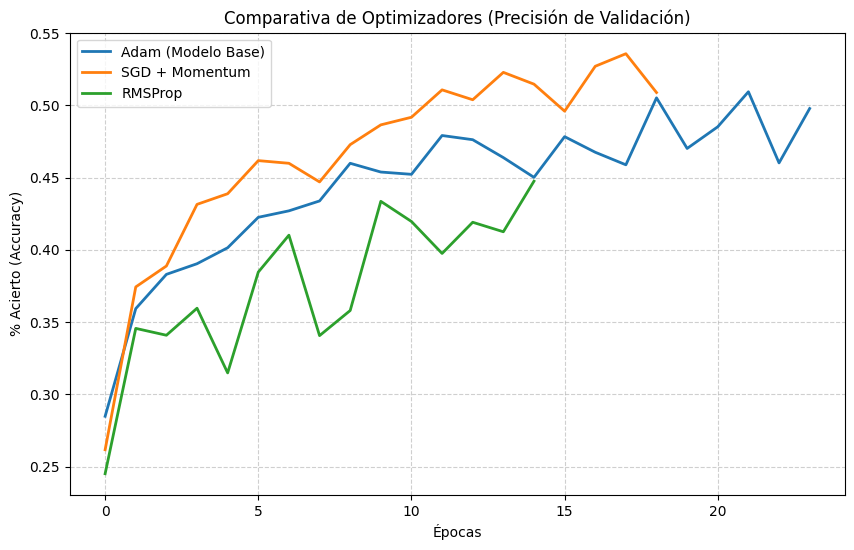

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(history_base.history['val_accuracy'], label='Adam (Modelo Base)', linewidth=2)
plt.plot(history_sgd.history['val_accuracy'], label='SGD + Momentum', linewidth=2)
plt.plot(history_rms.history['val_accuracy'], label='RMSProp', linewidth=2)

plt.title('Comparativa de Optimizadores (Precisión de Validación)')
plt.xlabel('Épocas')
plt.ylabel('% Acierto (Accuracy)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

## **Análisis: Adam vs. SGD + Momentum vs. RMSProp**

Se observa que SGD + Momentum logra el mejor desempeño, alcanzando valores cercanos al 54%, con una tendencia de crecimiento constante. Esto indica que el uso de momentum permite un aprendizaje más estable y eficiente, evitando estancamientos.

El optimizador Adam (modelo base) presenta un buen rendimiento inicial y una convergencia relativamente rápida, alcanzando alrededor de 50%, pero con algunas fluctuaciones y menor capacidad de mejora en etapas posteriores.

Por otro lado, RMSProp muestra un comportamiento más inestable, con variaciones en la precisión y un rendimiento inferior, sin lograr superar de forma consistente a los otros optimizadores.



---



## **Experimento 3: Aplicar regularización por Dropout**

Se incorpora la técnica de Dropout como método de regularización, con el objetivo de reducir el sobreajuste.

Dropout desactiva aleatoriamente un porcentaje de neuronas durante el entrenamiento, lo que obliga al modelo a aprender representaciones más robustas y menos dependientes de características específicas.

In [ ]:
model_dropout = Sequential([
    Dense(128, activation='relu', input_shape=(X.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(18, activation='softmax')
])

model_dropout.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


history_dropout = model_dropout.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.1157 - loss: 2.8580 - val_accuracy: 0.1106 - val_loss: 2.8013
Epoch 2/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.1202 - loss: 2.7996 - val_accuracy: 0.1106 - val_loss: 2.7966
Epoch 3/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.1216 - loss: 2.7962 - val_accuracy: 0.1108 - val_loss: 2.7963
Epoch 4/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.1203 - loss: 2.7976 - val_accuracy: 0.1111 - val_loss: 2.7953
Epoch 5/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.1203 - loss: 2.7972 - val_accuracy: 0.1111 - val_loss: 2.7955
Epoch 6/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.1203 - loss: 2.7972 - val_accuracy: 0.1121 - val_loss: 2.7943
Epoch 7/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.1203 - loss: 2.7967 - val_accuracy: 0.1116 - val_loss: 2.7948
Epoch 8/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.1205 - loss: 2

## Resultado Obtenido:

El modelo se quedó bloqueado en un 11.95% de accuracy desde la segunda época. Este valor coincide con la probabilidad de elegir siempre la clase más frecuente por azar, lo que significa que el modelo "se rindió" y dejó de extraer características útiles de las imágenes.

El Dropout es para modelos que aprenden demasiado (sobreajuste), pero en este caso, al apagar el 30% de las neuronas, dejamos a la red con muy poca capacidad para entender las imágenes. Fue como intentar resolver un rompecabezas al que le quitamos a la fuerza el 30% de las piezas: el modelo simplemente no pudo armar la imagen de los personajes y se quedó estancado en el nivel de acierto por azar.

## Modelo mayor capacidad + dropout

Tras observar que el Dropout bloqueó el aprendizaje en la red con menor tamaño, se realiza esta prueba aumentando el número de neuronas y capas. El objetivo es comprobar que una red con más "capacidad" puede soportar la técnica de Dropout, ya que dispone de suficientes conexiones para seguir aprendiendo aunque algunas se desactiven.

In [ ]:
model_exp = Sequential([
    Dense(256, activation='relu', input_shape=(X.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(18, activation='softmax')
])

model_exp.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_exp = model_exp.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.1089 - loss: 2.8530 - val_accuracy: 0.1119 - val_loss: 2.7270
Epoch 2/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 24s 50ms/step - accuracy: 0.1310 - loss: 2.7323 - val_accuracy: 0.1487 - val_loss: 2.6771
Epoch 3/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - accuracy: 0.1474 - loss: 2.6806 - val_accuracy: 0.1603 - val_loss: 2.6039
Epoch 4/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - accuracy: 0.1535 - loss: 2.6579 - val_accuracy: 0.1911 - val_loss: 2.5903
Epoch 5/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.1526 - loss: 2.6422 - val_accuracy: 0.1516 - val_loss: 2.5969
Epoch 6/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 43s 51ms/step - accuracy: 0.1570 - loss: 2.6263 - val_accuracy: 0.1977 - val_loss: 2.5755
Epoch 7/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 42s 52ms/step - accuracy: 0.1604 - loss: 2.6189 - val_accuracy: 0.2101 - val_loss: 2.5380
Epoch 8/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 24s 50ms/step - accuracy: 0.1658 - loss: 2

## Resultado Obtenido:

A diferencia del modelo pequeño que se quedó estancado en el 11%, esta red más grande logró avanzar hasta un 18.24% de acierto en validación. Esto confirma que el Dropout y el tamaño de la red deben ir de la mano.

Aunque el progreso es lento, la red demuestra que ahora sí puede procesar información. El Dropout del 30% obliga a este modelo más grande a buscar caminos alternativos para reconocer a los personajes, evitando que dependa de unas pocas neuronas.

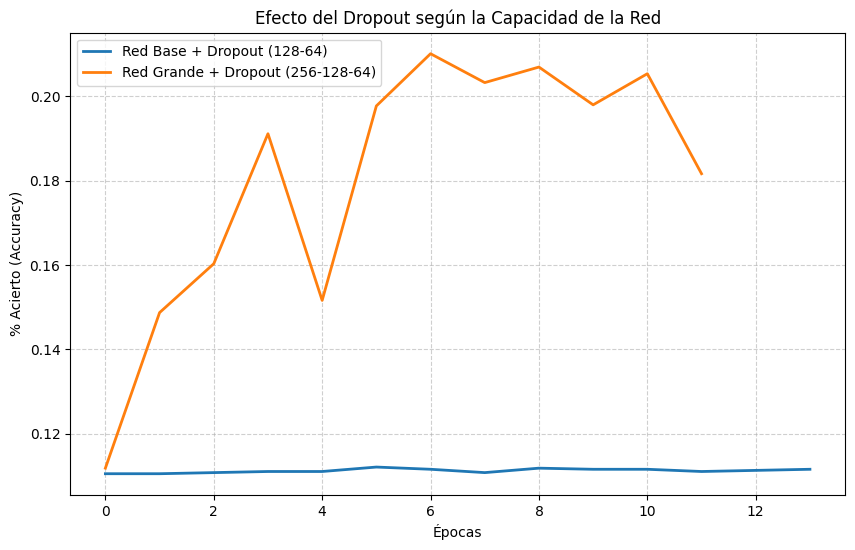

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(history_dropout.history['val_accuracy'], label='Red Base + Dropout (128-64)', linewidth=2)
plt.plot(history_exp.history['val_accuracy'], label='Red Grande + Dropout (256-128-64)', linewidth=2)

plt.title('Efecto del Dropout según la Capacidad de la Red')
plt.xlabel('Épocas')
plt.ylabel('% Acierto (Accuracy)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()



---



## **Análisis: Dropout**

Se observa que la red base con Dropout se queda estancada cerca del 11%, lo que indica que no logra aprender.

En cambio, la red más grande con Dropout sí mejora, alcanzando alrededor del 20%, lo que demuestra que puede aprender aunque más lentamente.

El Dropout no funciona bien en redes pequeñas porque reduce demasiado su capacidad.
Sin embargo, en redes más grandes sí permite aprender, ya que hay suficientes neuronas para compensar las que se desactivan.

## **Experimento 4: Modificar Learning rate (Mas alto)**

Se utiliza un Learning Rate de 0.01, buscando acelerar el aprendizaje. Sin embargo, una tasa demasiado alta puede causar inestabilidad, haciendo que el optimizador "salte" las zonas de menor error y no logre ajustar los pesos de manera precisa.

In [ ]:
model_lr_high = Sequential([
    Dense(128, activation='relu', input_shape=(X.shape[1],)),
    Dense(64, activation='relu'),
    Dense(18, activation='softmax')
])

model_lr_high.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_lr = model_lr_high.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.1158 - loss: 3.7660 - val_accuracy: 0.1106 - val_loss: 2.7976
Epoch 2/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.1202 - loss: 2.7964 - val_accuracy: 0.1106 - val_loss: 2.7961
Epoch 3/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.1202 - loss: 2.7964 - val_accuracy: 0.1106 - val_loss: 2.7970
Epoch 4/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.1202 - loss: 2.7964 - val_accuracy: 0.1106 - val_loss: 2.7981
Epoch 5/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.1202 - loss: 2.7969 - val_accuracy: 0.1106 - val_loss: 2.7983
Epoch 6/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.1202 - loss: 2.7968 - val_accuracy: 0.1106 - val_loss: 2.7984
Epoch 7/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.1202 - loss: 2.7969 - val_accuracy: 0.1106 - val_loss: 2.7974


## Resultado Obtenido:

Al aumentar la velocidad de aprendizaje, el modelo se bloqueó en un 11.95% de acierto. Esto pasó porque los ajustes eran tan bruscos que el optimizador "saltaba" por encima de las respuestas correctas sin llegar a aprender nada.

En lugar de bajar el error con cuidado, el modelo dio pasos demasiado grandes, rebotando de un lado a otro sin encontrar estabilidad.

El Early Stopping detuvo el experimento en la época 9. Al ver que el error no bajaba y el acierto no se movía del 11.9%, el sistema entendió que el modelo estaba en un círculo vicioso y decidió parar el entrenamiento para no perder tiempo.

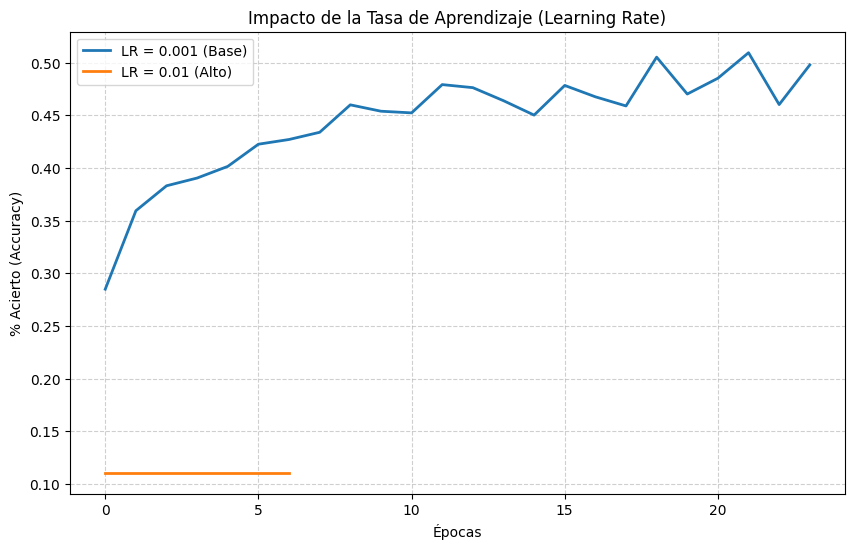

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(history_base.history['val_accuracy'], label='LR = 0.001 (Base)', linewidth=2)
plt.plot(history_lr.history['val_accuracy'], label='LR = 0.01 (Alto)', linewidth=2)

plt.title('Impacto de la Tasa de Aprendizaje (Learning Rate)')
plt.xlabel('Épocas')
plt.ylabel('% Acierto (Accuracy)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

## **Análisis: Learning Rate**
LR = 0.001 (Base): El modelo aprende de forma saludable y progresiva, ajustando sus pesos con "pasos" del tamaño adecuado.

LR = 0.01 (Alto): El aprendizaje es nulo. Los pasos son tan grandes que el optimizador "salta" por encima de las soluciones, dejando a la red totalmente estancada en el nivel del azar.



---



## **Experimento 5: Modificar batch size (mayor)**

En este experimento se modifica el tamaño del batch utilizado durante el entrenamiento.

El batch size afecta la estabilidad del entrenamiento y el uso de memoria, pudiendo influir en la velocidad de convergencia y en la generalización del modelo.

## Modelo con Batch 64

Se aumenta el tamaño del batch a 64 para proporcionar al modelo estimaciones del gradiente más estables. El objetivo es observar si procesar más ejemplos simultáneamente mejora la generalización y reduce las oscilaciones durante el entrenamiento.

In [ ]:
model_batch64 = Sequential([
    Dense(128, activation='relu', input_shape=(X.shape[1],)),
    Dense(64, activation='relu'),
    Dense(18, activation='softmax')
])

model_batch64.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_batch64 = model_batch64.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.2144 - loss: 2.6014 - val_accuracy: 0.3222 - val_loss: 2.2679
Epoch 2/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.3345 - loss: 2.1853 - val_accuracy: 0.3475 - val_loss: 2.1334
Epoch 3/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.3822 - loss: 2.0464 - val_accuracy: 0.3640 - val_loss: 2.1177
Epoch 4/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.4082 - loss: 1.9576 - val_accuracy: 0.3804 - val_loss: 2.0795
Epoch 5/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.4311 - loss: 1.8821 - val_accuracy: 0.4330 - val_loss: 1.9151
Epoch 6/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.4457 - loss: 1.8198 - val_accuracy: 0.4035 - val_loss: 2.0205
Epoch 7/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.4619 - loss: 1.7815 - val_accuracy: 0.3951 - val_loss: 2.0704
Epoch 8/100
238/238 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.4806 - loss: 1.6984 -

## Resultado Obtenido:

El modelo alcanzó un 49.01% de accuracy en validación, superando al modelo base. Esto confirma que ver más imágenes por cada ajuste de pesos ayuda a captar mejor los rasgos de los personajes.

El proceso fue más constante y menos errático. Al usar grupos de 64 imágenes, el optimizador recibe una señal más clara, evitando confusiones por imágenes individuales con mucho ruido.

El Early Stopping rescató la época 16 por tener la menor pérdida (val_loss: 1.7485), logrando un equilibrio sólido entre aprendizaje y capacidad de predicción.

## Modelo con Batch 128

Se aumenta el tamaño del grupo de imágenes (batch) a 128 para que el modelo aprenda de forma más estable. Al ver más ejemplos antes de hacer ajustes, se busca que el entrenamiento sea más fluido y rápido.

In [ ]:
model_batch128 = Sequential([
    Dense(128, activation='relu', input_shape=(X.shape[1],)),
    Dense(64, activation='relu'),
    Dense(18, activation='softmax')
])

model_batch128.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_batch128 = model_batch128.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=128,
    callbacks=[early_stop]
)

Epoch 1/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.1557 - loss: 2.8609 - val_accuracy: 0.2387 - val_loss: 2.4866
Epoch 2/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.2819 - loss: 2.3597 - val_accuracy: 0.3227 - val_loss: 2.2875
Epoch 3/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.3497 - loss: 2.1727 - val_accuracy: 0.3661 - val_loss: 2.1314
Epoch 4/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.3987 - loss: 2.0159 - val_accuracy: 0.3972 - val_loss: 2.0295
Epoch 5/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.4120 - loss: 1.9588 - val_accuracy: 0.4180 - val_loss: 1.9486
Epoch 6/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.4426 - loss: 1.8681 - val_accuracy: 0.4309 - val_loss: 1.9472
Epoch 7/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.4614 - loss: 1.7987 - val_accuracy: 0.4520 - val_loss: 1.8686
Epoch 8/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.4732 - loss: 1.7524 - 

## Resultado Obtenido:

Con el batch de 128, el modelo fue muy estable y no tuvo "sobresaltos", pero el aprendizaje se volvió un poco más lento. Nos quedamos con la época 21 porque fue el momento exacto donde el error dejó de bajar.

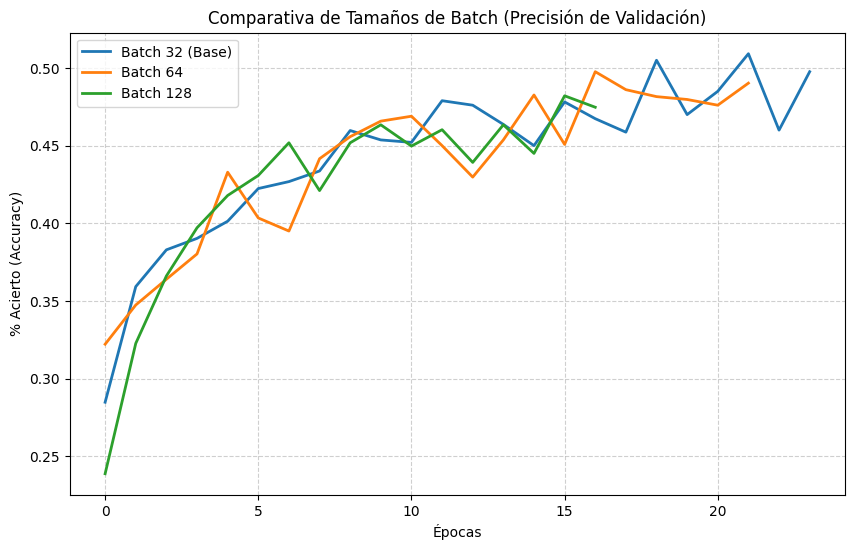

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(history_base.history['val_accuracy'], label='Batch 32 (Base)', linewidth=2)
plt.plot(history_batch64.history['val_accuracy'], label='Batch 64', linewidth=2)
plt.plot(history_batch128.history['val_accuracy'], label='Batch 128', linewidth=2)

plt.title('Comparativa de Tamaños de Batch (Precisión de Validación)')
plt.xlabel('Épocas')
plt.ylabel('% Acierto (Accuracy)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

## **Análisis: El impacto del tamaño de lote (Batch)**

Batch 32 (Ganador): Es la curva que alcanza los picos más altos de precisión. Al usar grupos pequeños de imágenes, el modelo actualiza sus pesos más seguido, permitiéndole encontrar mejores soluciones.

Batch 64 y 128: Menor precision. Al procesar muchas imágenes juntas, el modelo generaliza demasiado y pierde los detalles finos que sirven para diferenciar a un personaje de otro.



---



## **Experimento 6: Modificar cantidad de neuronas de la red (Aumentar)**

Se incrementa la complejidad del modelo utilizando una estructura de tres capas (256, 128 y 64 neuronas). El objetivo es determinar si una red más profunda y con más unidades de procesamiento puede capturar mejor los detalles visuales de los personajes de los Simpsons que el modelo base.

In [ ]:
model_neuronas = Sequential([
    Dense(256, activation='relu', input_shape=(X.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(18, activation='softmax')
])

model_neuronas.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_neuronas = model_neuronas.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.1585 - loss: 2.7018 - val_accuracy: 0.2495 - val_loss: 2.4149
Epoch 2/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - accuracy: 0.2766 - loss: 2.3259 - val_accuracy: 0.3572 - val_loss: 2.1035
Epoch 3/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.3542 - loss: 2.0962 - val_accuracy: 0.3943 - val_loss: 2.0221
Epoch 4/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - accuracy: 0.3976 - loss: 1.9619 - val_accuracy: 0.3772 - val_loss: 2.0260
Epoch 5/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.4280 - loss: 1.8651 - val_accuracy: 0.4277 - val_loss: 1.8819
Epoch 6/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 46s 64ms/step - accuracy: 0.4538 - loss: 1.7858 - val_accuracy: 0.4204 - val_loss: 1.9147
Epoch 7/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 38s 59ms/step - accuracy: 0.4765 - loss: 1.7078 - val_accuracy: 0.4283 - val_loss: 1.8814
Epoch 8/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 28s 58ms/step - accuracy: 0.4945 - loss: 1

## Resultado Obtenido:

El modelo logró su punto más alto con un 51.33% de acierto en validación. Esto confirma que al darle "más neuronas", la red tiene más herramientas para aprender patrones complejos que antes ignoraba.

Aunque el acierto en entrenamiento subió mucho (llegó al 68%), el de validación se estancó cerca del 51%. Esto indica que la red es tan potente que empezó a memorizar las imágenes de entrenamiento en lugar de solo aprender a reconocerlas.

El entrenamiento se detuvo en la época 17. El sistema rescató la época 12, que fue donde el error fue más bajo (1.6583), evitando que el modelo se volviera demasiado específico y perdiera su capacidad de generalizar.

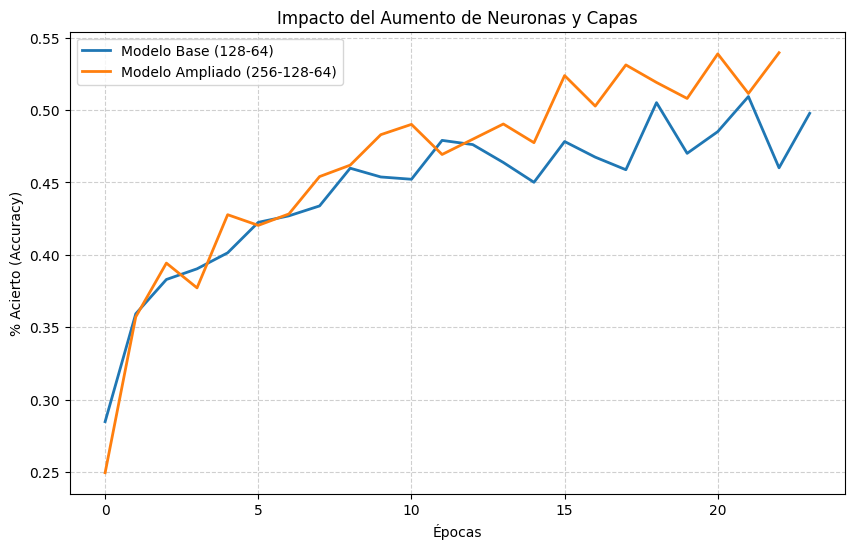

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(history_base.history['val_accuracy'], label='Modelo Base (128-64)', linewidth=2)
plt.plot(history_neuronas.history['val_accuracy'], label='Modelo Ampliado (256-128-64)', linewidth=2)

plt.title('Impacto del Aumento de Neuronas y Capas')
plt.xlabel('Épocas')
plt.ylabel('% Acierto (Accuracy)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

## **Análisis: Cantidad de neuronas**

Modelo Base (128-64): Se queda estancado cerca del 50%. Su estructura es demasiado sencilla para procesar todas las diferencias entre los 18 personajes; simplemente "ya no le cabe más información".

Modelo Ampliado (256-128-64): Al tener más neuronas, la red tiene una mayor "capacidad de memoria". Esto le permite encontrar patrones más específicos en las imágenes, logrando superar la barrera del modelo base y alcanzar mejores resultados.



---



## Modelo seleccionado

El modelo final es una evolución estratégica basada en los fallos y aciertos de los experimentos anteriores:

Capacidad (256-128-64): Se aumentó el número de neuronas para darle al modelo la "memoria" suficiente para procesar 18 clases distintas, evitando el estancamiento del modelo base.

Activación ReLU: ReLU: Permite un aprendizaje más eficiente evitando el desvanecimiento del gradiente.

Dropout (0.3): Evita que el modelo memorice y lo obliga a entender.

SGD + Momentum (0.9): Se seleccionó este optimizador porque demostró una trayectoria de aprendizaje más profunda y estable que Adam para este dataset.

Batch Size 32: Se eligió este tamaño de lote porque permite actualizaciones de pesos más frecuentes, logrando un ajuste más fino en la clasificación.

In [ ]:
model_final = Sequential([
    Dense(256, activation='relu', input_shape=(X.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(18, activation='softmax')
])

model_final.compile(
    optimizer=SGD(learning_rate=0.001, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_final = model_final.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 25s 47ms/step - accuracy: 0.1380 - loss: 2.7488 - val_accuracy: 0.1853 - val_loss: 2.5836
Epoch 2/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.2007 - loss: 2.5582 - val_accuracy: 0.2859 - val_loss: 2.4062
Epoch 3/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.2454 - loss: 2.4209 - val_accuracy: 0.3388 - val_loss: 2.2349
Epoch 4/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.2806 - loss: 2.3250 - val_accuracy: 0.3530 - val_loss: 2.1704
Epoch 5/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.3032 - loss: 2.2638 - val_accuracy: 0.3785 - val_loss: 2.1030
Epoch 6/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.3246 - loss: 2.1936 - val_accuracy: 0.3991 - val_loss: 2.0454
Epoch 7/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.3395 - loss: 2.1564 - val_accuracy: 0.4083 - val_loss: 2.0217
Epoch 8/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.3565 - loss: 2

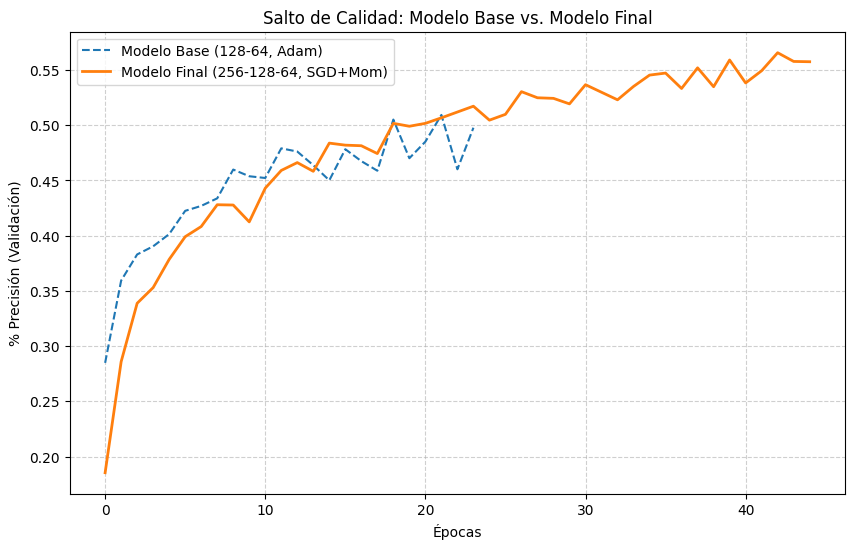

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(history_base.history['val_accuracy'], label='Modelo Base (128-64, Adam)', linestyle='--')
plt.plot(history_final.history['val_accuracy'], label='Modelo Final (256-128-64, SGD+Mom)', linewidth=2)

plt.title('Salto de Calidad: Modelo Base vs. Modelo Final')
plt.xlabel('Épocas')
plt.ylabel('% Precisión (Validación)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## **Análisis: Base vs Final**

Modelo Base (Línea Azul): Aunque empieza ganando velocidad (gracias a Adam), se nota que es muy inestable y "nervioso" (tiene muchos picos y caídas). Además, se queda sin "combustible" cerca de la época 20, demostrando que su arquitectura era muy pequeña para seguir mejorando.

Modelo Final (Línea Naranja): Empieza más lento, pero su crecimiento es mucho más sólido y constante. Al tener más neuronas y el apoyo del Momentum, logra superar el techo del modelo base y sigue aprendiendo hasta alcanzar un nivel de precisión mucho mayor.



---



## Evaluación de los modelos

Para determinar el mejor modelo, se sometieron todas las arquitecturas entrenadas a una prueba con datos que nunca habían visto (conjunto de test). El objetivo es medir su capacidad de generalización mediante cuatro métricas clave:

Accuracy (Exactitud): El porcentaje total de predicciones correctas.

Precision (Precisión): Qué tan confiable es el modelo cuando identifica a un personaje (evita falsos positivos).

Recall (Sensibilidad): La capacidad del modelo para encontrar a todos los personajes de una clase (evita falsos negativos).

F1-Score: El balance ideal entre Precisión y Recall, útil para saber si el modelo es equilibrado.

A continuación, se presenta la comparativa final ordenada por su rendimiento:

In [ ]:
resultados = []

modelos = {
    "Base (ReLU, Batch 32)": model_base,
    "Sigmoid": model_sigmoid,
    "Tanh": model_tanh,
    "SGD + Momentum": model_sgd,
    "RMSProp": model_rms,
    "Dropout 0.3": model_dropout,
    "Dropout + capacidad": model_exp,
    "LR Alto (0.01)": model_lr_high,
    "Batch 64": model_batch64,
    "Batch 128": model_batch128,
    "Más Neuronas (256)": model_neuronas,
    "Modelo final": model_final
}

print("Calculando métricas para todos los modelos... (Esto puede tardar un poco)")

for nombre, modelo in modelos.items():
    y_pred_prob = modelo.predict(X_t, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    acc = accuracy_score(y_t, y_pred)
    prec = precision_score(y_t, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_t, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_t, y_pred, average='weighted', zero_division=0)

    resultados.append([nombre, acc, prec, rec, f1])

df_resultados = pd.DataFrame(resultados, columns=["Modelo", "Accuracy", "Precision", "Recall", "F1-score"])

df_resultados.sort_values(by="Accuracy", ascending=False)

Calculando métricas para todos los modelos... (Esto puede tardar un poco)


,Modelo,Accuracy,Precision,Recall,F1-score
11,Modelo final,0.640449,0.681096,0.640449,0.630295
10,Más Neuronas (256),0.604494,0.650757,0.604494,0.604852
0,"Base (ReLU, Batch 32)",0.596629,0.641238,0.596629,0.595423
3,SGD + Momentum,0.588764,0.648841,0.588764,0.584677
8,Batch 64,0.551685,0.591843,0.551685,0.539382
9,Batch 128,0.480899,0.562989,0.480899,0.477603
4,RMSProp,0.423596,0.456212,0.423596,0.400764
1,Sigmoid,0.358427,0.306343,0.358427,0.314555
6,Dropout + capacidad,0.153933,0.058486,0.153933,0.080032
2,Tanh,0.056180,0.003156,0.056180,0.005977


## **Resultado Obtenido:**

El modelo final obtuvo el mejor rendimiento con un 64.04% de accuracy, superando al modelo base (59.66%) y a todas las demás configuraciones. Esto confirma que los ajustes realizados mejoraron la capacidad de generalización.

Los modelos con mayor capacidad (más neuronas) también mostraron buen desempeño (~60%), lo que indica que aumentar la complejidad ayuda a capturar mejor los patrones de las imágenes.

En cambio, configuraciones como Sigmoid, Tanh, Dropout mal aplicado y learning rate alto tuvieron resultados muy bajos (incluso cercanos al azar), demostrando que una mala elección de hiperparámetros puede impedir completamente el aprendizaje.

En general, las métricas de Precision, Recall y F1-score siguen la misma tendencia que el accuracy, lo que indica que el rendimiento del modelo es consistente y no está sesgado hacia ciertas clases.



---



## Matriz de confusión

Evaluando el MODELO FINAL con el conjunto de Prueba (Testing):
------------------------------------------------------------
Accuracy general en Test: 0.6404
Pérdida general en Test: 1.1979

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Reporte Detallado de Clasificación:
              precision    recall  f1-score   support

           0       0.73      0.46      0.56        48
           1       0.76      0.82      0.79        50
           2       0.41      0.36      0.38        50
           3       0.70      0.58      0.64        48
           4       0.77      0.92      0.84        50
           5       0.97      0.59      0.73        49
           6       0.69      0.36      0.47        50
           7       0.55      0.66      0.60        50
           8       0.93      0.74      0.82        50
           9       0.59      0.90      0.71        50
          10       0.64      0.46      0.53        50
          11       0.83      0.76      0.79        50
          12       0.63      0.

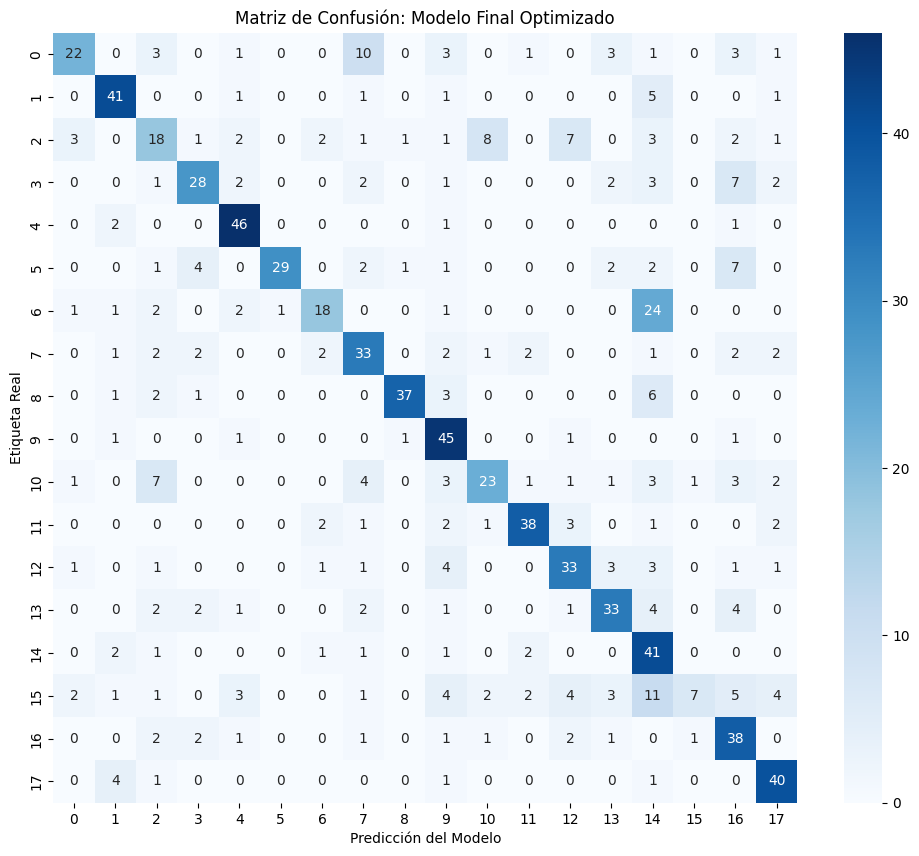

In [ ]:
print("Evaluando el MODELO FINAL con el conjunto de Prueba (Testing):")
print("-" * 60)

# 1. Pérdida y precisión general
test_loss, test_acc = model_final.evaluate(X_t, y_t, verbose=0)
print(f"Accuracy general en Test: {test_acc:.4f}")
print(f"Pérdida general en Test: {test_loss:.4f}\n")

# 2. Predicciones
y_pred_prob = model_final.predict(X_t)
y_pred = np.argmax(y_pred_prob, axis=1)

# 3. Reporte de Clasificación (Precision, Recall, F1-Score)
print("Reporte Detallado de Clasificación:")
print(classification_report(y_t, y_pred))

# 4. Matriz de Confusión Visual
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_t, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión: Modelo Final Optimizado')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')
plt.show()

### Los "Alumnos Estrella" (F1-Score > 0.75):

Los personajes 1, 4, 8, 11 y 17 tienen un desempeño excelente. Por ejemplo, la clase 5 tiene una precisión del 97%, lo que significa que cuando el modelo dice que es ese personaje, casi nunca se equivoca. Esto indica que estos personajes tienen rasgos físicos muy únicos que la red capturó a la perfección.

### El Desafío de la Confusión (F1-Score bajo):

Clase 15 (F1: 0.24): Es el punto más débil. Tiene un recall muy bajo (0.14), lo que significa que el modelo "no lo ve". Al mirar la matriz, vemos que se confunde frecuentemente con la clase 14.

Clase 2 y 6: También presentan dificultades. Esto suele ocurrir cuando los personajes comparten colores similares o fondos comunes (por ejemplo, varios personajes dentro de la casa de los Simpsons).

### Matriz de confusión:

La diagonal principal está bien marcada en la mayoría de los casos, lo que valida que el modelo ha aprendido correctamente.

Los puntos azules fuera de la diagonal muestran "parejas de confusión". Esto es normal en redes densas (no convolucionales), ya que el modelo se guía más por los colores globales de la imagen que por las formas exactas de las caras.



---



## Conclusión

El modelo demuestra una capacidad sólida para clasificar personajes con rasgos distintivos, logrando un balance de 0.68 en precisión y 0.64 en recall. El salto de calidad desde el azar (5.6%) hasta el 64.04% confirma que la arquitectura optimizada con 256 neuronas, SGD y Dropout es efectiva para este problema de alta complejidad.

Sin embargo, un factor determinante en el rendimiento fue el desbalance de clases. Al tener personajes con 2,000 imágenes (como Homero) frente a otros con solo 300 (como Nelson), el modelo tiende a especializarse en los más frecuentes. Para futuras iteraciones, el rendimiento podría mejorar significativamente si evitamos esto.



---

